<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-41-softmax-regression-multinomial-lr?scriptVersionId=345396441" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🤖 ML 41 — Softmax Regression | Multinomial LR
---

In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [32]:
df = sns.load_dataset('iris')

df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [33]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])

df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [34]:
df = df[['sepal_length','petal_length','species']]
df

,sepal_length,petal_length,species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0
...,...,...,...
145,6.7,5.2,2
146,6.3,5.0,2
147,6.5,5.2,2
148,6.2,5.4,2


In [35]:
X = df.drop(columns=["species"])
y = df.species

In [36]:
X_train,X_test,y_train,y_test = train_test_split(X, y, random_state=2)

In [37]:
clf = LogisticRegression()
clf.fit(X_train,y_train)

LogisticRegression()

In [38]:
y_pred = clf.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.9473684210526315


In [39]:
pd.DataFrame(confusion_matrix(y_test,y_pred))

,0,1,2
0,16,0,0
1,0,10,1
2,0,1,10


In [40]:
query = pd.DataFrame(
    [[3.4, 2.7]],
    columns=X_train.columns
)

clf.predict_proba(query)

array([[7.36455271e-01, 2.62988170e-01, 5.56559327e-04]])

In [41]:
clf.predict(query)

array([0])

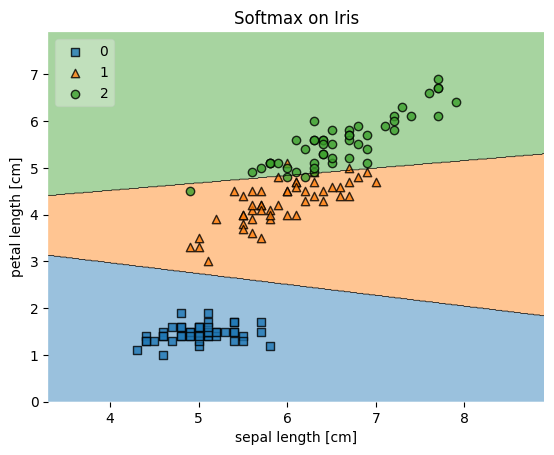

In [42]:
import warnings

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="X does not have valid feature names"
    )

    plot_decision_regions(X.values, y.values, clf, legend=2)

plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.title('Softmax on Iris')

plt.show()